<a href="https://colab.research.google.com/github/JuanGonzalezb/Bootcamp-DS-Yasser_Stev_Rodriguez---Cohorte-202604/blob/main/Proyecto_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **PROYECTO FINAL**

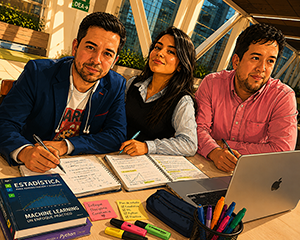


>Este proyecto fue realizado por 3 estudiantes del curso de Programación de datos | Grupo 1

*Juan David González Bedon* <br>
*Fabian Manios Ascencio*<br>
*Alexandra Ruiz Castro*



In [1]:
import pandas as pd

# Instalar Sodapy para poder usar el API Socrata
!pip install sodapy

# Ahora descargamos el archivo y lo guardamos localmente en Google Colab
from sodapy import Socrata


client = Socrata("www.datos.gov.co", None)
results = client.get("ruiv-deeb")
siniestros_palmira = pd.DataFrame.from_records(results)
siniestros_palmira.to_csv("siniestros_raw.csv")

In [2]:
siniestros_palmira

,a_o,hora,jornada,dia_semana,barrios_coregimiento_via,direccion,zona,autoridad,lat,long,codigo_hipotesis,condicion_de_la_victima,clase_de_siniestro,involucrdos_en_siniestros,sexo,homicidios
0,2020,1899-12-31T10:10:00.000,MAÑANA,MIERCOLES,VIA PALMASECA - EL CERRITO,KM 13 + 500 MTS,RURAL,POLICIA,3.61752,-76.39617,411,PEATON,ATROPELLO,MICROBUS - PEATON,MASCULINO,1
1,2020,1899-12-31T22:00:00.000,NOCHE,SABADO,VIA PALMIRA - PRADERA,KM 81 + 800 MTS,RURAL,POLICIA,3.51080,-76.26473,121,ACOMPAÑANTE MOTOCICLISTA,CHOQUE,MOTO - MOTO,FEMENINA,1
2,2020,1899-12-31T10:00:00.000,MAÑANA,MIERCOLES,VIA PALMASECA - EL CERRITO,KM 15 + 300 MTS,RURAL,POLICIA,3.63378,-76.38705,104,MOTOCICLISTA,CHOQUE,MOTO - MOTO,MASCULINO,1
3,2020,1899-12-31T18:50:00.000,NOCHE,DOMINGO,VIA PALMASECA - EL CERRITO,KM 7 + 250 MTS,RURAL,POLICIA,3.56512,-76.41170,104,MOTOCICLISTA,CHOQUE,MOTO - BUS,MASCULINO,1
4,2020,1899-12-31T20:30:00.000,NOCHE,MIERCOLES,VIA CALI - PALMIRA SUR,KM 7 + 400 MTS,RURAL,POLICIA,3.50559,-76.42150,121,MOTOCICLISTA,CHOQUE,MOTO- MOTO,MASCULINO,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,2020,1899-12-31T09:20:00.000,MAÑANA,MIERCOLES,LAS FLOREZ,CALLE 30 CARRERA 4-03,URBANA,TECNICO,3.52247,-76.27974,157,MOTOCICLISTA,CHOQUE,MOTO -MOTO -AUTOMOVIL,MASCULINO,1
74,2020,1899-12-31T19:00:00.000,NOCHE,DOMINGO,LAS PALMERAS,CALLE 35 CARRERA 2,URBANA,TECNICO,3.53184,-76.27855,157,MOTOCICLISTA,CHOQUE,MOTO - MOTO,MASCULINO,1
75,2020,1899-12-31T23:00:00.000,NOCHE,MARTES,VIA ZONA FRANCA DE PALMASECA,GLORIETA AEROPUERTO,RURAL,TECNICO,3.53489,-76.38964,157,MOTOCICLISTA,CHOQUE MURO,MOTO,MASCULINO,1
76,2020,1899-12-31T18:30:00.000,NOCHE,MARTES,MERCEDES,CARRERA 28 CALLE 54,URBANA,TECNICO,3.54668,-76.29573,157,MOTOCICLISTA,CHOQUE,MOTO - AUTOMOVIL,MASCULINO,NaN


In [3]:
from google.colab import files
files.download("siniestros_raw.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
# Verificamos información sobre formato de data

siniestros_palmira.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   a_o                        78 non-null     object
 1   hora                       78 non-null     object
 2   jornada                    78 non-null     object
 3   dia_semana                 78 non-null     object
 4   barrios_coregimiento_via   78 non-null     object
 5   direccion                  78 non-null     object
 6   zona                       78 non-null     object
 7   autoridad                  78 non-null     object
 8   lat                        78 non-null     object
 9   long                       78 non-null     object
 10  codigo_hipotesis           78 non-null     object
 11  condicion_de_la_victima    78 non-null     object
 12  clase_de_siniestro         78 non-null     object
 13  involucrdos_en_siniestros  78 non-null     object
 14  sexo        

In [5]:
#Cantidad de datos con vacios

siniestros_palmira.isnull().sum()

,0
a_o,0
hora,0
jornada,0
dia_semana,0
barrios_coregimiento_via,0
direccion,0
zona,0
autoridad,0
lat,0
long,0


In [6]:
int(siniestros_palmira.duplicated().sum())


4

In [7]:
int(siniestros_palmira["homicidios"].isnull().sum())

1

In [8]:
# Reemplazar vacios de columna de homicidios

siniestros_palmira["homicidios"] = siniestros_palmira["homicidios"].fillna(0)

In [9]:
# Validar reemplazo de datos

siniestros_palmira.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   a_o                        78 non-null     object
 1   hora                       78 non-null     object
 2   jornada                    78 non-null     object
 3   dia_semana                 78 non-null     object
 4   barrios_coregimiento_via   78 non-null     object
 5   direccion                  78 non-null     object
 6   zona                       78 non-null     object
 7   autoridad                  78 non-null     object
 8   lat                        78 non-null     object
 9   long                       78 non-null     object
 10  codigo_hipotesis           78 non-null     object
 11  condicion_de_la_victima    78 non-null     object
 12  clase_de_siniestro         78 non-null     object
 13  involucrdos_en_siniestros  78 non-null     object
 14  sexo        

In [12]:
#Reemplazar dato para cambiarlo a formato de hora

siniestros_palmira["hora"] = siniestros_palmira["hora"].replace("06.30", "1899-12-31T06:30:00.000")

In [13]:
siniestros_palmira["hora"].head(10)

,hora
0,1899-12-31T10:10:00.000
1,1899-12-31T22:00:00.000
2,1899-12-31T10:00:00.000
3,1899-12-31T18:50:00.000
4,1899-12-31T20:30:00.000
5,1899-12-31T16:50:00.000
6,1899-12-31T23:45:00.000
7,1899-12-31T23:45:00.000
8,1899-12-31T23:45:00.000
9,1899-12-31T06:30:00.000


In [14]:
siniestros_palmira["hora"].str.split("T").str[1]

,hora
0,10:10:00.000
1,22:00:00.000
2,10:00:00.000
3,18:50:00.000
4,20:30:00.000
...,...
73,09:20:00.000
74,19:00:00.000
75,23:00:00.000
76,18:30:00.000


In [15]:
#Extracción primera parte del texto para dejar solo e formato de hora

siniestros_palmira["hora"].str.split("T").str[1].str.split(".").str[0]

,hora
0,10:10:00
1,22:00:00
2,10:00:00
3,18:50:00
4,20:30:00
...,...
73,09:20:00
74,19:00:00
75,23:00:00
76,18:30:00


In [16]:
#Cambiart tipo de contenido de object a date

siniestros_palmira["hora"] = pd.to_datetime(siniestros_palmira["hora"], errors="coerce")

In [17]:
#Revisar cambio  realizado

siniestros_palmira.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   a_o                        78 non-null     object        
 1   hora                       78 non-null     datetime64[ns]
 2   jornada                    78 non-null     object        
 3   dia_semana                 78 non-null     object        
 4   barrios_coregimiento_via   78 non-null     object        
 5   direccion                  78 non-null     object        
 6   zona                       78 non-null     object        
 7   autoridad                  78 non-null     object        
 8   lat                        78 non-null     object        
 9   long                       78 non-null     object        
 10  codigo_hipotesis           78 non-null     object        
 11  condicion_de_la_victima    78 non-null     object        
 12  clase_de_s

In [18]:
siniestros_palmira["homicidios"].value_counts()


,count
homicidios,
1,77
0,1


In [19]:
# verificar categorias de la columna clase de siniestro

siniestros_palmira["clase_de_siniestro"].value_counts()

,count
clase_de_siniestro,
CHOQUE,49
ATROPELLO,12
VOLCAMIENTO,6
CHOQUE ARBOL,4
CHOQUE OBJETO FIJO ARBOL,3
CHOQUE OBJETO FIJO POSTE,1
CHOQUE OBJETO FIJO BARANDA,1
CHOQUE MURO,1
CHOQUE POSTE,1


In [20]:
# Convierto a lower el texto de la columa antes de separarlo

siniestros_palmira["clase_de_siniestro"] = siniestros_palmira["clase_de_siniestro"].str.lower()

In [26]:
# Separa columna clase de sieniestro y Crea la columna 'objeto' tomando la primera palabra antes del espacio

# Divide el texto por el espacio y asigna los dos valores resultantes

siniestros_palmira[['clase_de_siniestro', 'objeto']] = (
    siniestros_palmira['clase_de_siniestro'].str.split(' ', n=1, expand=True)
)

In [28]:
siniestros_palmira.head(-10)

,a_o,hora,jornada,dia_semana,barrios_coregimiento_via,direccion,zona,autoridad,lat,long,codigo_hipotesis,condicion_de_la_victima,clase_de_siniestro,involucrdos_en_siniestros,sexo,homicidios,objeto
0,2020,1899-12-31 10:10:00,MAÑANA,MIERCOLES,VIA PALMASECA - EL CERRITO,KM 13 + 500 MTS,RURAL,POLICIA,3.61752,-76.39617,411,PEATON,atropello,MICROBUS - PEATON,MASCULINO,1,<NA>
1,2020,1899-12-31 22:00:00,NOCHE,SABADO,VIA PALMIRA - PRADERA,KM 81 + 800 MTS,RURAL,POLICIA,3.51080,-76.26473,121,ACOMPAÑANTE MOTOCICLISTA,choque,MOTO - MOTO,FEMENINA,1,<NA>
2,2020,1899-12-31 10:00:00,MAÑANA,MIERCOLES,VIA PALMASECA - EL CERRITO,KM 15 + 300 MTS,RURAL,POLICIA,3.63378,-76.38705,104,MOTOCICLISTA,choque,MOTO - MOTO,MASCULINO,1,<NA>
3,2020,1899-12-31 18:50:00,NOCHE,DOMINGO,VIA PALMASECA - EL CERRITO,KM 7 + 250 MTS,RURAL,POLICIA,3.56512,-76.41170,104,MOTOCICLISTA,choque,MOTO - BUS,MASCULINO,1,<NA>
4,2020,1899-12-31 20:30:00,NOCHE,MIERCOLES,VIA CALI - PALMIRA SUR,KM 7 + 400 MTS,RURAL,POLICIA,3.50559,-76.42150,121,MOTOCICLISTA,choque,MOTO- MOTO,MASCULINO,1,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,2020,1899-12-31 05:30:00,MADRUGADA,DOMINGO,VAI CALI - PALMIRA NORTE,KM 18 + 100 MTS,RURAL,TECNICO,3.52673,-76.32826,157,ACOMPAÑANTE MOTOCICLISTA,volcamiento,MOTO,FEMENINA,1,<NA>
64,2020,1899-12-31 00:50:00,MADRUGADA,SABADO,CENTRO POBLADO ROZO,AVENIDAD 9 N 13-831,RURAL,TECNICO,3.61585,-76.38879,157,MOTOCICLISTA,choque,MOTO-POSTE,MASCULINO,1,<NA>
65,2020,1899-12-31 14:30:00,TARDE,SABADO,VIA PALMIRA GUAYABAL,PREDIO K3 + 252,RURAL,TECNICO,3.54613,-76.26432,157,ACOMPAÑANTE MOTOCICLISTA,volcamiento,MOTO,FEMENINA,1,<NA>
66,2020,1899-12-31 12:30:00,TARDE,SABADO,VIA CALI - PALMIRA SUR,KM 13 + 950 MTS,RURAL,POLICIA,3.51856,-76.36425,157,ACOMPAÑANTE CONDUCTOR,choque,AUTOMOVIL - ARBOL,MASCULINO,1,<NA>


In [29]:
siniestros_palmira = siniestros_palmira.astype({
    "jornada": "string",
    "dia_semana": "string",
    "barrios_coregimiento_via": "string",
    "direccion": "string",
    "zona": "string",
    "autoridad": "string",
    "condicion_de_la_victima": "string",
    "clase_de_siniestro": "string",
    "involucrdos_en_siniestros": "string",
    "sexo": "string",
    "objeto": "string"})

In [30]:
siniestros_palmira.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   a_o                        78 non-null     object        
 1   hora                       78 non-null     datetime64[ns]
 2   jornada                    78 non-null     string        
 3   dia_semana                 78 non-null     string        
 4   barrios_coregimiento_via   78 non-null     string        
 5   direccion                  78 non-null     string        
 6   zona                       78 non-null     string        
 7   autoridad                  78 non-null     string        
 8   lat                        78 non-null     object        
 9   long                       78 non-null     object        
 10  codigo_hipotesis           78 non-null     object        
 11  condicion_de_la_victima    78 non-null     string        
 12  clase_de_s

# ***RECOMENDACIONES***

1	Hay una hora que está 6.30, debemos acomodarla (reemplazar) para que quede como si fuera hora de verdad.

> #*done A.R*


2	La columna hora está en formato fecha. Debemos extraer para que solo tenga la hora.

> #*done A.R*


3	La columna jornada está bien. No hay que hacerle nada.


4	La columna clase_de_siniestro, podemos separarla entre choque y vehículo.


5	Lo mismo la columna involucrdos_en_siniestros.


6	La columna homicidios. Recomiendo llenar de 0 los vacíos

> #*done A.R*



In [ ]:
# 1. ¿En qué franjas horarias y días de la semana se concentran los siniestros más graves?

siniestros_analisis = siniestros_palmira.loc[~siniestros_palmira.duplicated()].copy()
siniestros_analisis["homicidios_num"] = siniestros_analisis["homicidios"].astype(int)
siniestros_graves = siniestros_analisis.loc[siniestros_analisis["homicidios_num"] > 0]

gravedad_dia_jornada = siniestros_graves.pivot_table(
    index="dia_semana",
    columns="jornada",
    values="homicidios_num",
    aggfunc="sum",
    fill_value=0
)
display(gravedad_dia_jornada)

gravedad_dia_jornada.plot.bar(
    stacked=True,
    figsize=(12, 6),
    title="Siniestros con homicidio por día y jornada",
    xlabel="Día de la semana",
    ylabel="Cantidad de homicidios",
    rot=45
)

concentracion = siniestros_graves.groupby(["dia_semana", "jornada"]).size().sort_values(ascending=False)
concentracion_maxima = concentracion.loc[concentracion == concentracion.max()]
display(concentracion_maxima)
display(f"Respuesta: existe un empate entre domingo en la madrugada, sábado en la mañana y sábado en la tarde, con {int(concentracion_maxima.iloc[0])} registros con homicidio en cada combinación.")

In [ ]:
# 2. ¿Qué diferencias existen entre siniestros en zona urbana vs. rural (tipo, gravedad, actores)?

resumen_zona = siniestros_analisis.groupby("zona").agg(
    total_siniestros=("zona", "size"),
    homicidios=("homicidios_num", "sum")
)
resumen_zona["porcentaje_homicidios"] = (resumen_zona["homicidios"] / resumen_zona["total_siniestros"] * 100).round(1)
resumen_zona["tipo_principal"] = ""
resumen_zona["actor_principal"] = ""

tipo_urbana = siniestros_analisis.loc[siniestros_analisis["zona"] == "URBANA", "clase_de_siniestro"].value_counts()
tipo_rural = siniestros_analisis.loc[siniestros_analisis["zona"] == "RURAL", "clase_de_siniestro"].value_counts()
actor_urbana = siniestros_analisis.loc[siniestros_analisis["zona"] == "URBANA", "condicion_de_la_victima"].value_counts()
actor_rural = siniestros_analisis.loc[siniestros_analisis["zona"] == "RURAL", "condicion_de_la_victima"].value_counts()

resumen_zona.loc["URBANA", "tipo_principal"] = tipo_urbana.index[0]
resumen_zona.loc["RURAL", "tipo_principal"] = tipo_rural.index[0]
resumen_zona.loc["URBANA", "actor_principal"] = actor_urbana.index[0]
resumen_zona.loc["RURAL", "actor_principal"] = actor_rural.index[0]
display(resumen_zona)

resumen_zona[["total_siniestros", "homicidios"]].plot.bar(
    figsize=(8, 5),
    title="Comparación de siniestros y homicidios por zona",
    xlabel="Zona",
    ylabel="Cantidad",
    rot=0
)

display(f"Respuesta: en la zona urbana hay {int(resumen_zona.loc['URBANA', 'total_siniestros'])} registros, predomina '{tipo_urbana.index[0]}' y el actor principal es {actor_urbana.index[0].lower()}; el {resumen_zona.loc['URBANA', 'porcentaje_homicidios']:.1f}% presenta homicidio. En la zona rural hay {int(resumen_zona.loc['RURAL', 'total_siniestros'])} registros, también predomina '{tipo_rural.index[0]}' y el actor principal es {actor_rural.index[0].lower()}; el {resumen_zona.loc['RURAL', 'porcentaje_homicidios']:.1f}% presenta homicidio.")

In [ ]:
# 3. ¿Qué actor vial (peatón, motociclista, ciclista) está más expuesto y en qué condiciones?

actores_objetivo = ["PEATON", "MOTOCICLISTA", "CICLISTA"]
siniestros_actores = siniestros_analisis.loc[siniestros_analisis["condicion_de_la_victima"].isin(actores_objetivo)]
exposicion_actores = siniestros_actores["condicion_de_la_victima"].value_counts()
display(exposicion_actores)

exposicion_actores.sort_values().plot.barh(
    figsize=(8, 5),
    title="Exposición por actor vial",
    xlabel="Cantidad de siniestros",
    ylabel="Actor vial"
)

actor_mayor = exposicion_actores.index[0]
datos_actor_mayor = siniestros_actores.loc[siniestros_actores["condicion_de_la_victima"] == actor_mayor]
dia_actor = datos_actor_mayor["dia_semana"].value_counts().index[0]
jornada_actor = datos_actor_mayor["jornada"].value_counts().index[0]
zona_actor = datos_actor_mayor["zona"].value_counts().index[0]
tipo_actor = datos_actor_mayor["clase_de_siniestro"].value_counts().index[0]

display(f"Respuesta: el actor vial más expuesto es el {actor_mayor.lower()}, con {int(exposicion_actores.iloc[0])} registros. Se concentra principalmente el día {dia_actor.lower()}, en la {jornada_actor.lower()}, en zona {zona_actor.lower()} y en siniestros tipo '{tipo_actor}'.")

In [ ]:
# 4. ¿Qué vías o sectores concentran más siniestros y podrían priorizarse para intervención?

sectores_prioritarios = siniestros_analisis["barrios_coregimiento_via"].value_counts().head(10)
display(sectores_prioritarios)

sectores_prioritarios.sort_values().plot.barh(
    figsize=(11, 6),
    title="Vías o sectores con mayor concentración de siniestros",
    xlabel="Cantidad de siniestros",
    ylabel="Vía o sector"
)

display(f"Respuesta: la prioridad principal es '{sectores_prioritarios.index[0]}', con {int(sectores_prioritarios.iloc[0])} registros. Le siguen '{sectores_prioritarios.index[1]}' con {int(sectores_prioritarios.iloc[1])} y '{sectores_prioritarios.index[2]}' con {int(sectores_prioritarios.iloc[2])}.")

In [ ]:
# 5. ¿Existe relación entre el tipo de vehículos involucrados y la severidad (homicidios)?

resumen_vehiculos = siniestros_analisis.groupby("involucrdos_en_siniestros").agg(
    casos=("involucrdos_en_siniestros", "size"),
    homicidios=("homicidios_num", "sum")
)
resumen_vehiculos["porcentaje_homicidios"] = (resumen_vehiculos["homicidios"] / resumen_vehiculos["casos"] * 100).round(1)
vehiculos_repetidos = resumen_vehiculos.loc[resumen_vehiculos["casos"] >= 2].sort_values("casos", ascending=False).head(10)
display(vehiculos_repetidos)

vehiculos_repetidos["porcentaje_homicidios"].sort_values().plot.barh(
    figsize=(11, 6),
    title="Porcentaje de homicidios por vehículos involucrados",
    xlabel="Porcentaje de registros con homicidio",
    ylabel="Vehículos involucrados"
)

total_homicidios = int(siniestros_analisis["homicidios_num"].sum())
total_registros = len(siniestros_analisis)
display(f"Respuesta: no se puede afirmar una relación diferencial sólida entre el tipo de vehículo y la severidad, porque {total_homicidios} de {total_registros} registros presentan homicidio y las combinaciones repetidas muestran porcentajes prácticamente iguales. Se necesita mayor variación entre casos con y sin homicidio para establecer esa relación.")